# **Section 1: CNV Data Exploration and Preprocessing**

This notebook explores the CNV depth matrix and prepares data for ML modeling. It focuses on removing outliers, ensuring data consistency and handling missing values. 

**Contents:**
1. Load data
2. Visualize feature distributions per sample
3. Identify and remove outliers
4. Handle missing values
5. Save preprocessed data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
sns.set_palette("pastel")

## **1. Load Data**

In [33]:
cnv_matrix = pd.read_csv('cnv_depth_matrix.tsv', sep='\t', index_col=0)

print(f'Feature Matrix Shape: {cnv_matrix.shape}')
print(f'\nFirst few samples and regions:')
print(cnv_matrix.iloc[:5,:5])
print(f'\nData types: {cnv_matrix.dtypes.unique()}')
print(f'\nMissing values (NaN): {cnv_matrix.isna().sum().sum()} / {cnv_matrix.size} ({100*cnv_matrix.isna().sum().sum()/cnv_matrix.size:.2f}%)')

Feature Matrix Shape: (227, 23338)

First few samples and regions:
            cnv_depth__IBNLCO_00001__IBNLCO_00001__gene  \
sample                                                    
SRR3404582                                     0.456210   
SRR3404597                                     0.501361   
SRR3404599                                     0.456717   
SRR5927082                                     0.365460   
SRR6075123                                     0.481897   

            cnv_depth__unknown__unknown__source  \
sample                                            
SRR3404582                            -0.064161   
SRR3404597                            -0.049432   
SRR3404599                            -0.061306   
SRR5927082                            -0.097766   
SRR6075123                            -0.087126   

            cnv_depth__IBNLCO_00001__Putative__CDS  \
sample                                               
SRR3404582                                0.456210   

## **2. Feature exploration**

### **2.1 Summary Statistics Per Sample**

In [34]:
# Calculate per-sample statistics
sample_stats = pd.DataFrame({
    "sample": cnv_matrix.index,
    "mean": cnv_matrix.mean(axis=1).values,
    "median": cnv_matrix.median(axis=1).values,
    "std": cnv_matrix.std(axis=1).values,
    "min": cnv_matrix.min(axis=1).values,
    "max": cnv_matrix.max(axis=1).values,
    "q25": cnv_matrix.quantile(0.25, axis=1).values,
    "q75": cnv_matrix.quantile(0.75, axis=1).values,
    "nan_count": cnv_matrix.isna().sum(axis=1).values
})

sample_stats["iqr"] = sample_stats["q75"] - sample_stats["q25"]


In [35]:
sample_stats = sample_stats.set_index("sample")

In [36]:
print('Sample Statistics Summary:')
print(f"   Average: {sample_stats['mean'].mean()}")
print(f"   Max value: {sample_stats['max'].max()}")
print(f"   Min value: {sample_stats['min'].min()}")
print(f"   Total NaN counts: {sample_stats['nan_count'].sum()}")

Sample Statistics Summary:
   Average: -0.07144956292469233
   Max value: 6.437405312307298
   Min value: -15.393658591454772
   Total NaN counts: 102313


We see that the average log2(copy_number) is close to 0, which suggests that on average, samples have **one** copy of each region of interest, as expected. We also see that we have a very high max value (6.4) which biologically doesn't make sense, which is someting we will have to investigate. The Min value is very low, suggesting that there are regions that are barely covered. This is also evident by the high amount of NaN values (more than 10'000) which represent genes that aren't expressed. We will need to adress these values later on.  

### **2.2 Summary Statistics Visualizations**

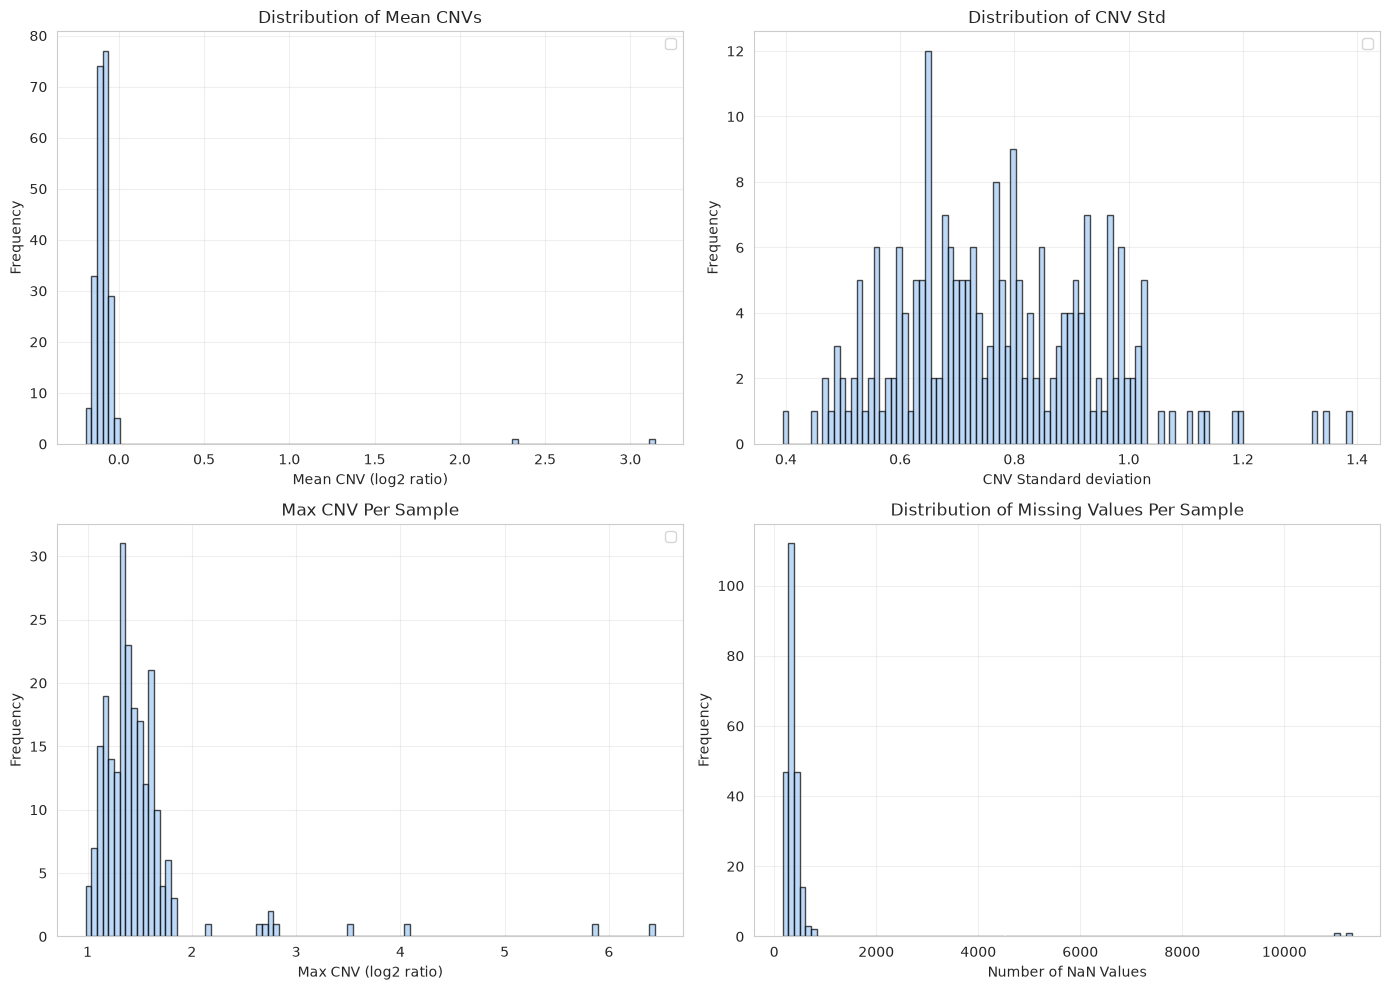

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean distribution
axes[0, 0].hist(sample_stats["mean"], bins=100, alpha=0.7, edgecolor="black")
axes[0, 0].set_xlabel("Mean CNV (log2 ratio)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Distribution of Mean CNVs")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Standard deviation distribution
axes[0, 1].hist(sample_stats["std"], bins=100, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel("CNV Standard deviation")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Distribution of CNV Std")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Max value distribution
axes[1, 0].hist(sample_stats["max"], bins=100, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel("Max CNV (log2 ratio)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Max CNV Per Sample")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# NaN count distribution
axes[1, 1].hist(sample_stats["nan_count"], bins=100, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel("Number of NaN Values")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Distribution of Missing Values Per Sample")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cnv_01_statistics.png", dpi=300, bbox_inches='tight')
plt.show()

We see that there are two samples that have a much higher mean than the others. We will likely have to filter out these samples. Likely, there are two samples that have a very high number of missing values (genes not expressed). These are also outliers and we will likely need to filter them out. 

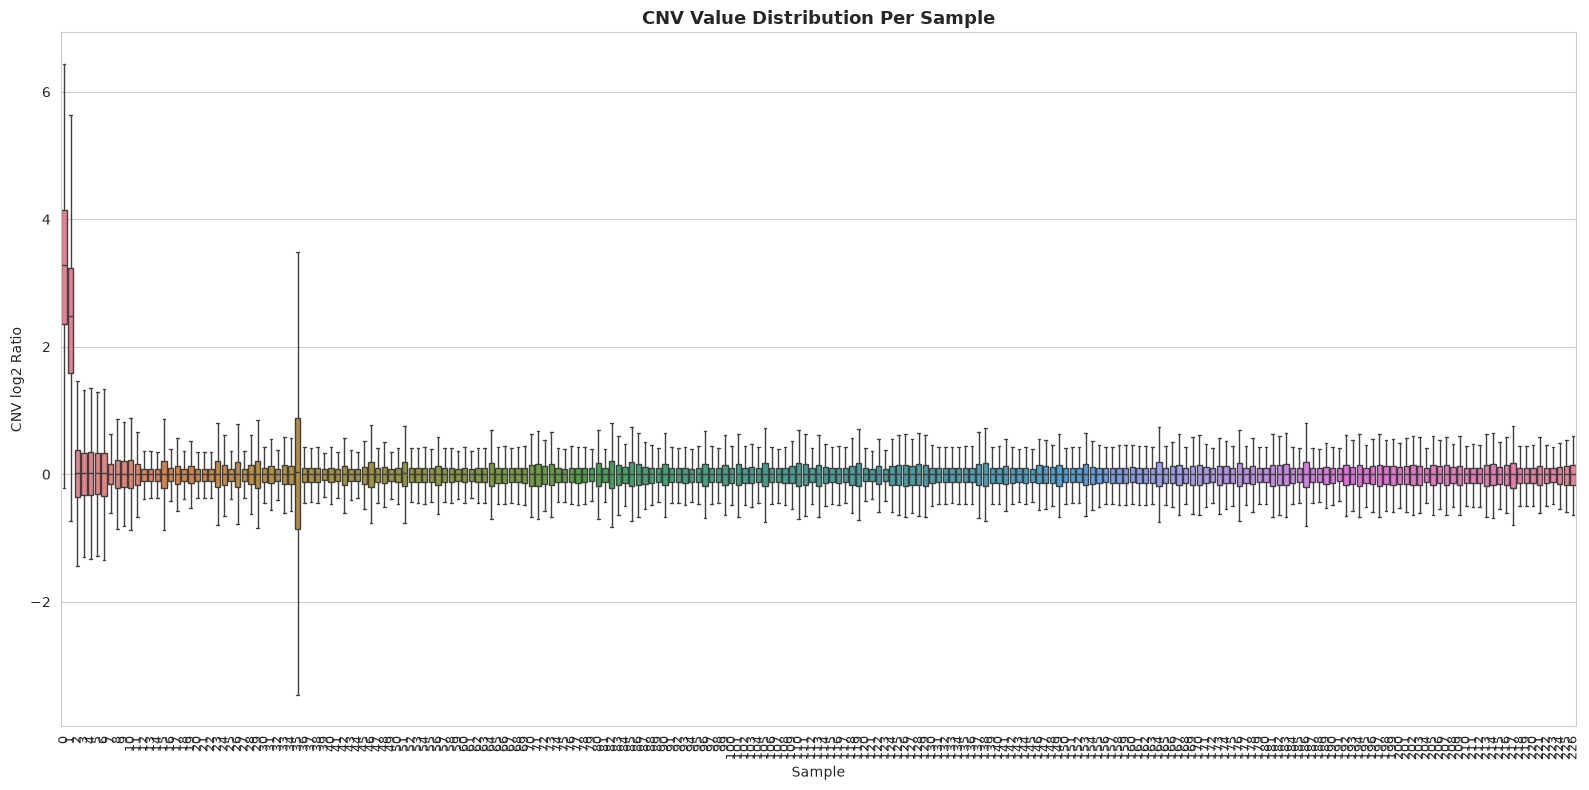

Boxplot saved


In [9]:
# Sort samples by mean CNV for plotting
sorted_samples = sample_stats.sort_values('mean', ascending=False).index

fig, ax = plt.subplots(figsize=(16, 8))

# Create boxplot
cnv_sorted = cnv_matrix.loc[sorted_samples]
sns.boxplot(cnv_sorted.T.values, showfliers=False)

ax.set_xlabel("Sample")
ax.set_ylabel("CNV log2 Ratio")
ax.set_title("CNV Value Distribution Per Sample", fontweight='bold', fontsize=13)
plt.xticks(rotation=90, fontsize=9)
plt.tight_layout()
plt.savefig("cnv_01_boxplot_per_sample.png", dpi=300, bbox_inches='tight')
plt.show()

We see that most samples center around 0, as expected. However, we have two samples that have a much higer mean, and one with a much higher standard deviation. We will have to remove these samples from the analysis.

## **3. Outlier Removal**
Let's adress the outliers. We will start by identifying outliers (in terms of mean, standard deviation, and number of NaN values) by setting a thershold corresponding to the mean of the metric + 2x the standard deviation. 

### **3.1 Identify Outliers**

In [63]:
# Define outlier criteria
#sample_stats.reset_index(inplace=True)
mean_threshold = sample_stats["mean"].mean() + 2 * sample_stats["mean"].std()
std_threshold = sample_stats["std"].mean() + 2 * sample_stats["std"].std()
nan_threshold = sample_stats["nan_count"].mean() + 2 * sample_stats["nan_count"].std()

print(f"Mean threshold: {mean_threshold:.2f}")
print(f"Std threshold: {std_threshold:.2f}")
print(f"NaN threshold: {nan_threshold:.2f}")

# Identify outliers
outlier_mean = sample_stats[sample_stats["mean"] > mean_threshold]
outlier_std = sample_stats[sample_stats["std"] > std_threshold]
outlier_nan = sample_stats[sample_stats["nan_count"] > nan_threshold]

print("\nSamples with high mean CNV:")
print(outlier_mean.index.tolist())

print("\nSamples with high std dev:")
print(outlier_std.index.tolist())

print("\nSamples with high nan counts:")
print(outlier_nan.index.tolist())

# Combine all outliers
all_outliers = pd.concat([outlier_mean, outlier_std, outlier_nan]).drop_duplicates()
print(f'\nTotal outliers: {len(all_outliers)}')
print(f'Outliers: {all_outliers.index.tolist()}')

Mean threshold: 0.47
Std threshold: 1.12
NaN threshold: 2489.04

Samples with high mean CNV:
['SRR27387856', 'SRR27388139']

Samples with high std dev:
['SRR27387759', 'SRR27387856', 'SRR27387950', 'SRR27388077', 'SRR27388102', 'SRR27388139']

Samples with high nan counts:
['SRR27387856', 'SRR27388139']

Total outliers: 6
Outliers: ['SRR27387856', 'SRR27388139', 'SRR27387759', 'SRR27387950', 'SRR27388077', 'SRR27388102']


### **3.2 Remove Outliers**

In [64]:
print(f'Original shape: {cnv_matrix.shape[0]}')

# Remove outliers
cnv_filtered = cnv_matrix.drop(index=all_outliers.index)

print(f'Outliers removed: {len(all_outliers)}')
print(f'Remaining samples: {cnv_filtered.shape[0]}')
print(f'\nRemoved samples: {all_outliers.index.tolist()}')

Original shape: 227
Outliers removed: 6
Remaining samples: 221

Removed samples: ['SRR27387856', 'SRR27388139', 'SRR27387759', 'SRR27387950', 'SRR27388077', 'SRR27388102']


## **4. Handle Missing Values (NaN)**
We will replace missing values with an arbitrarilly low number (-20). These missing regions correspond to absent genes and should thus be around 0. 

In [67]:
print(f'NaN values before filling in: {cnv_filtered.isna().sum().sum()} / {cnv_filtered.size}')

cnv_filtered.fillna(-20, inplace=True)

print(f"NaN values after filling in: {cnv_filtered.isna().sum().sum()}")

NaN values before filling in: 78824 / 5157698
NaN values after filling in: 0


## **5. Save Data**

In [70]:
cnv_filtered.to_csv('cnv_filtered.tsv', sep='\t')